### `Loading libraries`

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


### `Fetching Dataset using pandas`

In [144]:
df = pd.read_csv("bank-full.csv", sep = ";")
df.head(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


### `Data inspection`

In [145]:
# Checking shape of the dataset.
print(f"Shape of the dataset:\nRows are {df.shape[0]}, Columnns are {df.shape[1]}")

Shape of the dataset:
Rows are 45211, Columnns are 17


In [146]:
# checking size of the dataset.
print('Size of the dataset is:',df.size)

Size of the dataset is: 768587


In [147]:
# Checking memory usage by the dataset.
df.memory_usage(deep = True).sum()/1024**2

np.float64(25.74866771697998)

```
The memory usage is high and can be optimised by converting datatypes which we will do in the following process so that machine work efficiently.
```

In [148]:
# Understanding data types of the features.
df.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

```
Data type is str in many features which is redundant and may consume large memory which may also reduce the machine speed during data processing. Thus we will change data type of required features from str to category so that we can optimise memory usage.
```

### `Data preparation and preprocessing`

In [149]:
# Understanding data type and the max values of the numerical features so that we can change the
# data types of the features as per their ranges optimize memory usage.
print(f"{'Column':20} | {'dtype':15} | {'Max Value':15}")
print("-"*50)
for i in df.select_dtypes(include = [np.number]).columns:
    print(f"{i:20} | {str(df[i].dtype):15} | {df[i].max():8.2f}")
    

Column               | dtype           | Max Value      
--------------------------------------------------
age                  | int64           |    95.00
balance              | int64           | 102127.00
day                  | int64           |    31.00
duration             | int64           |  4918.00
campaign             | int64           |    63.00
pdays                | int64           |   871.00
previous             | int64           |   275.00


In [150]:
print(f"{'Column':13} | {'dtype':7} | {'Unique Values':7}")
print("-"*40)
cat_variable = df.select_dtypes(include = [str]).columns
for i in cat_variable:
    print(f"{i:13} | {str(df[i].dtype):7} | {df[i].nunique():7}")

Column        | dtype   | Unique Values
----------------------------------------
job           | str     |      12
marital       | str     |       3
education     | str     |       4
default       | str     |       2
housing       | str     |       2
loan          | str     |       2
contact       | str     |       3
month         | str     |      12
poutcome      | str     |       4
y             | str     |       2


In [151]:
# changing data types of the features to reduce memory usage.
df = df.astype(
    {"age": "int16",
     "day": "int16",
     "duration": "int32",
     "pdays": "int16",
     "previous": "int16",
     "campaign": "int16",
     "job": "category",
     "marital": "category",
     "education": "category",
     "default": "category",
     "housing": "category",
     "loan": "category",
     "contact": "category",
     "month": "category",
     "poutcome": "category",
     "y": "category"
     })


In [152]:
# Recalculating the memory usage after changing the data types of the features.
df.memory_usage(deep = True).sum()/1024**2

np.float64(1.3822612762451172)

```
Now, we can clearly see that after allocating data types to the columns as per their need, the size of the memory usage has requced significanlty from 26 MB to almost 1.4 MB. This optimisation of the memory usage will enhace the machine processing.
```

In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int16   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int16   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int32   
 12  campaign   45211 non-null  int16   
 13  pdays      45211 non-null  int16   
 14  previous   45211 non-null  int16   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  category
dtypes: category(10), int16(5), int32(1), int64(1)
memory usage: 1.4 MB


In [154]:
# Checking for missing values in the dataset.
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [155]:
# Checking for duplicate records in the dataset.
df.duplicated().sum()

np.int64(0)

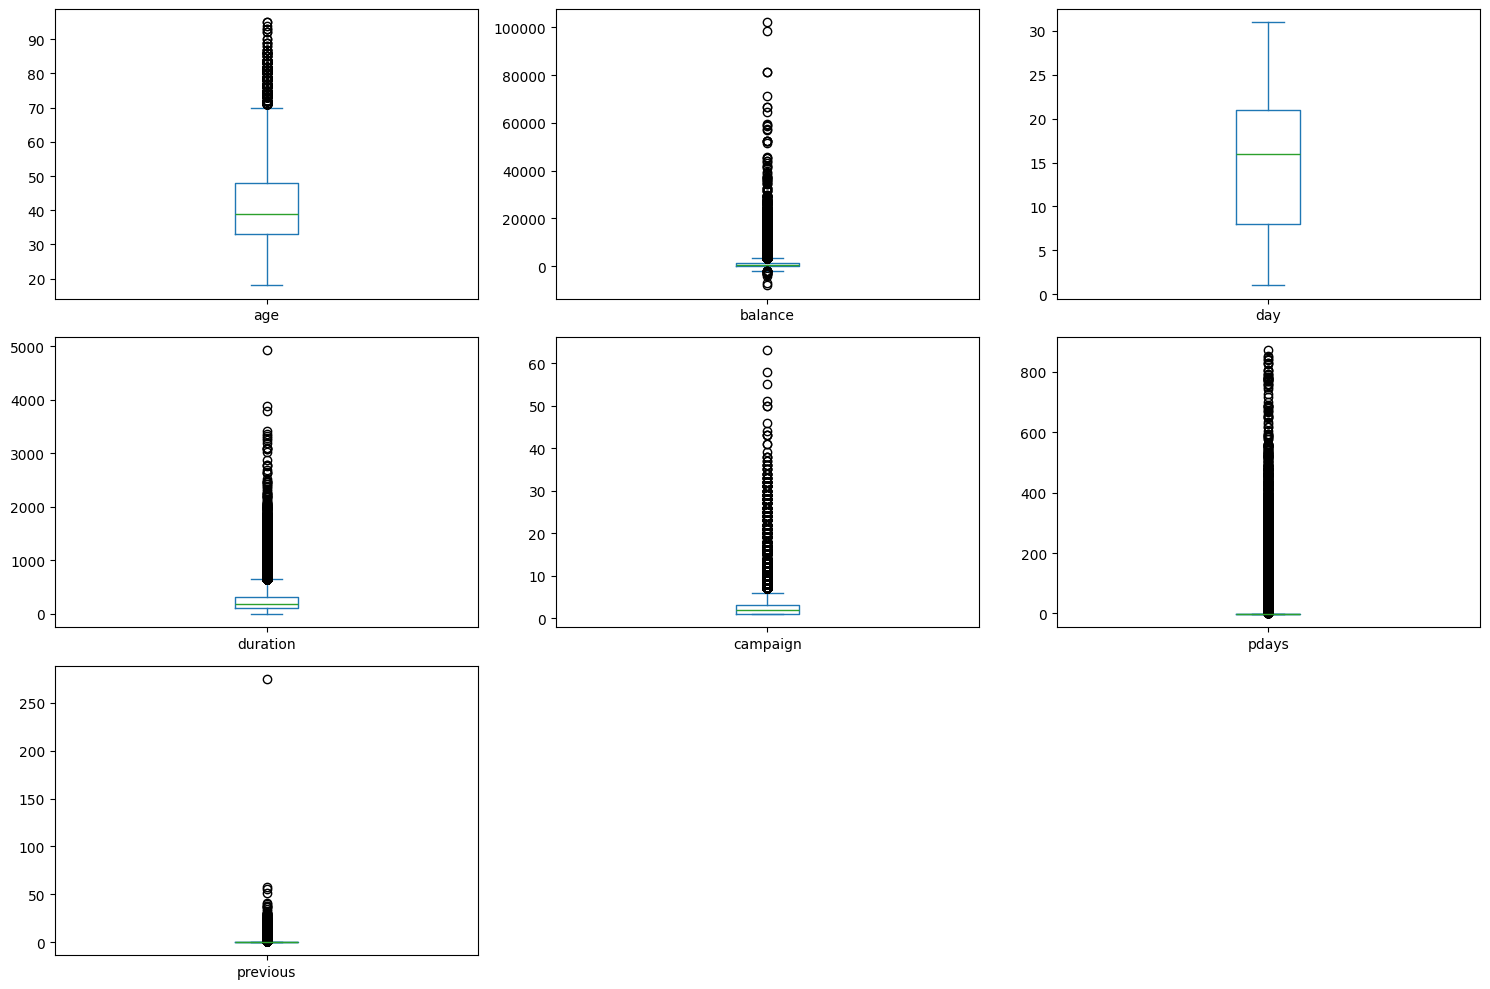

In [156]:
# Checking Outliers in the numerical features using boxplot.
numerical_features = df.select_dtypes(include = [np.number]).columns
df[numerical_features].plot(kind = "box", subplots = True, layout = (3,3), figsize = (15,10))
plt.tight_layout()

In [157]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


```
We will use statistical details of the data and will rectify the dataset.
1) "previous": max value is 275 while other mean is only 0.58. Thus 258 may be outlier.
```

In [158]:
# Checking number of tuple that have values between 30 and 275.
df[(df["previous"] <= 275) & (df["previous"] > 30)].shape[0]

12

```
Only 12 tuples in "previous" which have value between 30 and 275.
```

In [159]:
# Checking number of tuple in "previous" that have value 275.
df[df["previous"]== 275]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
29182,40,management,married,tertiary,no,543,yes,no,cellular,2,feb,349,2,262,275,other,no


```
Only 1 tuple in "previous" having value 275. Thus we can count it as an outlier.
```

In [160]:
# Removing tuple 29182 as it is an outlier.
df.drop(29182, inplace = True)

```
Tuple 29182 removed.
```

In [161]:
# Checking number of tuples between different ranges of column "pdays"
for i in range(1,871, 100):
    A = df[(df["pdays"] <= 871) & (df["pdays"] > i)].shape[0]
    print(f"Between {i:3} and 871: {A:4} tuples")
    

Between   1 and 871: 8241 tuples
Between 101 and 871: 6789 tuples
Between 201 and 871: 3941 tuples
Between 301 and 871: 2439 tuples
Between 401 and 871:  233 tuples
Between 501 and 871:  106 tuples
Between 601 and 871:   52 tuples
Between 701 and 871:   32 tuples
Between 801 and 871:   11 tuples


```
Here we can see number of tuples with different values are reducing smoothly. Thus we can not say tuples of last ranges are outliers.
```

In [162]:
# Understanding the scope of outlier in column "campaign"
for i in range(-1,63, 15):
    A = df[(df["campaign"] <= 63) & (df["campaign"] > i)].shape[0]
    print(f"Tuples in column 'campaign' with value between {i:3} and 63 are: {A:5} ")

Tuples in column 'campaign' with value between  -1 and 63 are: 45210 
Tuples in column 'campaign' with value between  14 and 63 are:   614 
Tuples in column 'campaign' with value between  29 and 63 are:    67 
Tuples in column 'campaign' with value between  44 and 63 are:     7 
Tuples in column 'campaign' with value between  59 and 63 are:     1 


In [ ]:
# Applying cap on large tuples which have large values.
df['campaign'] = np.clip(df['campaign'], -1, 30)

<Axes: ylabel='Frequency'>

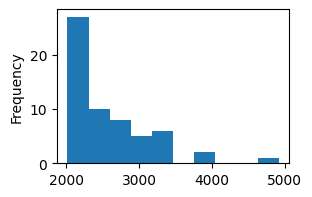

In [ ]:
# Checking outliers in column "duration"
df[(df["duration"] <= 4918 ) & (df["duration"] > 2000 )]["duration"].plot(kind = "hist", figsize=(3,2))

In [ ]:
# Applying cap as we will trin ANN model which may face negative effects due to outliers.
df['duration'] = np.clip(df['duration'], 0, 2500)